In [1]:
import numpy as np
import pandas as pd 

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('ggplot')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10,7

import sys
sys.path.append('src')

## Data Preparation

- Download the data from: http://www.kibot.com/buy.aspx at the: "Free historical data for your data quality analysis" section
- We have the data from the WDC stock and the iShares IVE ETF: https://www.ishares.com/us/products/239728/ishares-sp-500-value-etf 

#### Tick Data info from kibot
- http://www.kibot.com/support.aspx#data_format
- The order of the fields in the tick files (with bid/ask prices) is: Date,Time,Price,Bid,Ask,Size. 
- The bid/ask prices are recorded whenever a trade occurs and they represent the "national best bid and offer" (NBBO) prices across multiple exchanges and ECNs.
- For each trade, current best bid/ask values are recorded together with the transaction price and volume. Trade records are not aggregated and all transactions are included in their consecutive order.
- The order of fields in our regular tick files (without bid/ask) is: Date,Time,Price,Size.
- The order of fields in our 1, 5 or 10 second files is: Date,Time,Open,High,Low,Close,Volume. It is the same format used in our minute files.
- The stocks and ETFs data includes pre-market (8:00-9:30 a.m. ET), regular (9:30 a.m.-4:00 p.m. ET.) and after market (4:00-6:30 p.m. ET) sessions.
- Trading for SPY (SPDR S&P 500 ETF) and some other liquid ETFs and stocks usually starts at 4 a.m and ends at 8 p.m. ET.

___

In [2]:
def vwap_agg(g):
    total_vol = g['vol'].sum()
    vwap = g['dollar_vol'].sum() / total_vol if total_vol > 0 else np.nan

    return pd.Series({
        'price': vwap,
        'bid': g['bid'].iloc[-1],
        'ask': g['ask'].iloc[-1],
        'vol': total_vol,
        'dollar_vol': g['dollar_vol'].sum(),
        'trade_count': len(g),
        'price_high': g['price'].max(),
        'price_low': g['price'].min(),
    })


def prepare_data_kibot(raw_data_path, out_data_path):
    df = pd.read_csv(raw_data_path,
                     header=None,
                     names=['day', 'time', 'price', 'bid', 'ask', 'vol'])
    df['date'] = pd.to_datetime(df['day'] + df['time'],
                                format='%m/%d/%Y%H:%M:%S')
    df['dollar_vol'] = df['price'] * df['vol']
    df = df.set_index('date')
    df = df.drop(['day', 'time'],
                 axis=1)
    df = df.groupby(level=0, sort=True).apply(vwap_agg)
    df.to_parquet(out_data_path)

In [3]:
raw_data_path = '../data/raw/IVE_tickbidask.txt'
out_data_path = '../data/interim/IVE_tickbidask.parq'
prepare_data_kibot(raw_data_path, out_data_path)

In [4]:
raw_data_path = '../data/raw/WDC_tickbidask.txt'
out_data_path = '../data/interim/WDC_tickbidask.parq'
prepare_data_kibot(raw_data_path, out_data_path)

KeyboardInterrupt: 

### Data Cleaning
___

In [5]:
def mad_outlier(y, thresh=3.):
    '''
    compute outliers based on mad
    # args
        y: assumed to be array with shape (N,1)
        thresh: float()
    # returns
        array index of outliers
    '''
    y = np.expand_dims(y, axis=1)
    median = np.median(y)
    diff = np.sum((y - median)**2, axis=-1)
    diff = np.sqrt(diff)
    med_abs_deviation = np.median(diff)

    modified_z_score = 0.6745 * diff / med_abs_deviation

    return modified_z_score > thresh

In [6]:
#out_data_path = 'data/interim/WDC_tickbidask.parq'
out_data_path = '../data/interim/IVE_tickbidask.parq'
df = pd.read_parquet(out_data_path)

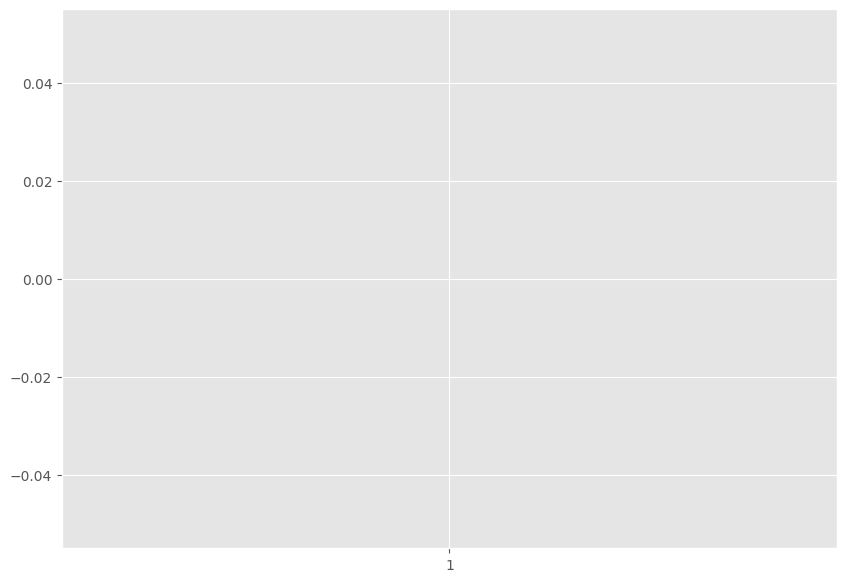

In [7]:
fig, ax = plt.subplots()
_ = ax.boxplot(df.price)

In [8]:
mad = mad_outlier(df.price.values)

In [9]:
print(mad.sum())

0


In [10]:
### drop the incorrect rows
df = df.loc[~mad]

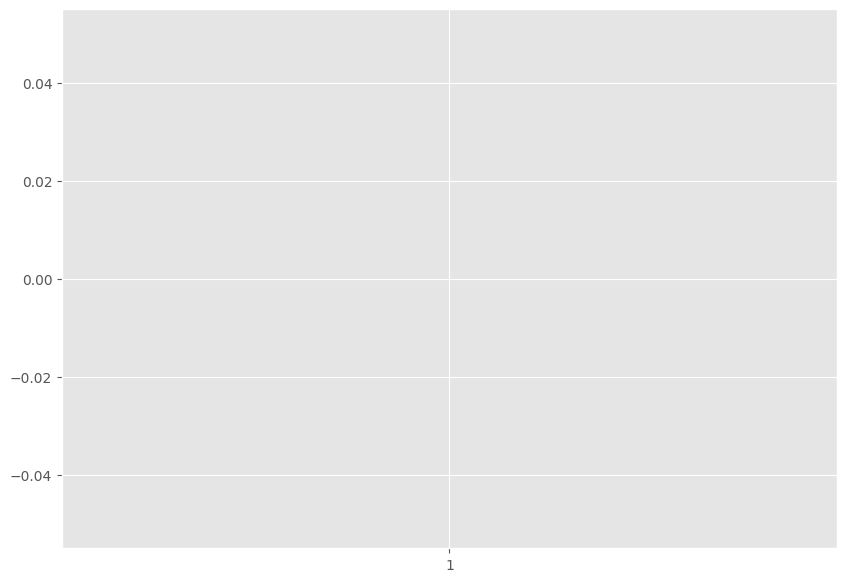

In [11]:
fig, ax = plt.subplots()
_ = ax.boxplot(df.price)

In [12]:
# Compatibility workflow; prefer: python utils/prepare_data.py kibot
clean_data_path = '../data/processed/clean_IVE_tickbidask.parquet'
df.to_parquet(clean_data_path, compression='zstd')

### Test clean data loading

In [13]:
clean_data_path = '../data/processed/clean_IVE_tickbidask.parquet'
df = pd.read_parquet(clean_data_path)

In [14]:
df.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:30:00,50.72084,50.70,50.79,738.0,37431.98,2.0,50.79,50.71
2009-09-28 09:31:32,50.75000,50.75,50.76,200.0,10150.00,2.0,50.75,50.75
2009-09-28 09:31:33,50.75000,50.72,50.75,800.0,40600.00,8.0,50.75,50.75
2009-09-28 09:31:50,50.75000,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:31:51,50.75000,50.74,50.76,300.0,15225.00,1.0,50.75,50.75
